
1. Import the car_service_data CSV file. Write a code to return all the column names in the DataFrame. Check the data types of the DataFrame.

In [1]:

import pandas as pd

df = pd.read_csv("Datasets_50_Days_Of_Data_Analysis/car_service_data.csv")
df.head()

,Service ID,Service Type,Service Cost,Service Revenue,Number of Customers,Advertising Cost,Location
0,1,Oil Change,$25,$50,10,$100,Urban
1,2,Brake Repair,$200,$500,5,$50,Suburban
2,3,Tire Rotation,$30,$75,12,$150,Rural
3,4,Transmission Repair,$1000,$2500,2,$200,Urban
4,5,Battery Replacement,$150,$300,8,$75,Suburban


In [2]:

df.columns

Index(['Service ID', 'Service Type', 'Service Cost', 'Service Revenue',
       'Number of Customers', 'Advertising Cost', 'Location'],
      dtype='object')

In [3]:

df.dtypes

Service ID              int64
Service Type           object
Service Cost           object
Service Revenue        object
Number of Customers     int64
Advertising Cost       object
Location               object
dtype: object


2. Which location has the highest service costs? Plot a bar plot using Seaborn to visualize the service costs by location.

In [4]:
df2 = df.copy()

# Creating a function to clean the data
def modify_df(df):
    df["Service Revenue"] = df["Service Revenue"].str.replace("$", "").astype(int)
    df["Service Cost"] = df["Service Cost"].str.replace("$", "").astype(int)
    df["Advertising Cost"] = df["Advertising Cost"].str.replace("$", "").astype(int)
    return df

modify_df(df2)

df2.head()

,Service ID,Service Type,Service Cost,Service Revenue,Number of Customers,Advertising Cost,Location
0,1,Oil Change,25,50,10,100,Urban
1,2,Brake Repair,200,500,5,50,Suburban
2,3,Tire Rotation,30,75,12,150,Rural
3,4,Transmission Repair,1000,2500,2,200,Urban
4,5,Battery Replacement,150,300,8,75,Suburban


In [5]:
group_by_location = df2.groupby("Location").sum()

# Sort data by location in ascending order
group_by_location.sort_values(by="Service Cost", ascending=False)

,Service ID,Service Type,Service Cost,Service Revenue,Number of Customers,Advertising Cost
Location,,,,,,
Urban,70,Oil ChangeTransmission RepairAC RechargeDetail...,2225,5350,42,750
Suburban,77,Brake RepairBattery ReplacementSuspension Repa...,2050,4950,67,625
Rural,63,Tire RotationEngine DiagnosticRadiator FlushFu...,655,1650,72,575


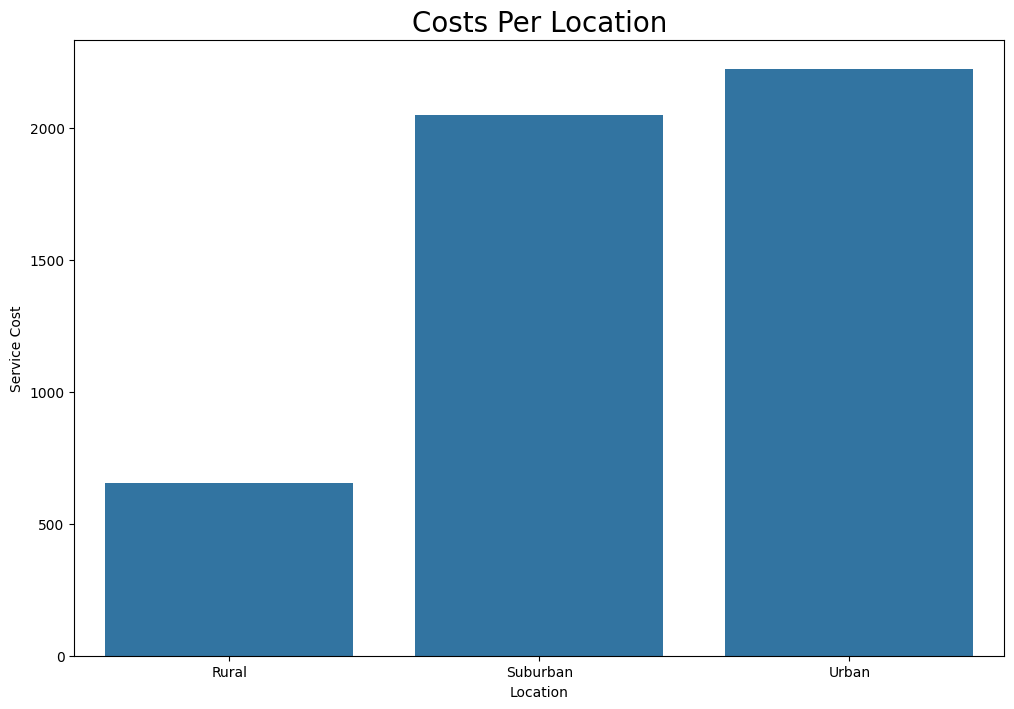

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=group_by_location.index, 
            y=group_by_location["Service Cost"], 
            data=group_by_location)
ax.set_title('Costs Per Location', fontsize=20)
plt.show()


3. Which location has the highest number of customers? Using pandas and Matplotlib, plot a line plot of location and number of customers.

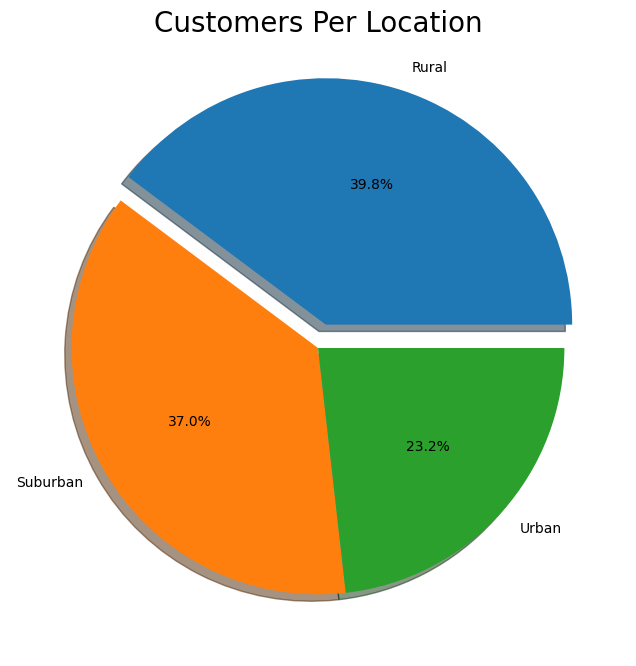

In [7]:
# Grouping the data by location
df_group = df2.groupby("Location")["Number of Customers"].sum()

plt.figure(figsize=(12, 8))
plt.pie(df_group, explode=(0.1, 0, 0), 
       labels=df_group.index, 
       autopct='%1.1f%%',
       shadow=True, 
       )

plt.title("Customers Per Location", fontsize=20)
plt.show()


4. Using the pandas groupby() method, group the data by location and find the average profit margin per location. Format your output to 1 decimal place and present it as a percentage.

In [8]:
df2['Profit'] = df2['Service Revenue'] - df2['Service Cost']
df2['Profit Margin'] = df2['Profit'] / df2['Service Revenue']*100
                                        
df2.groupby('Location')['Profit Margin'].mean().map('{:,.1f}%'.format)

Location
Rural       60.4%
Suburban    55.8%
Urban       56.5%
Name: Profit Margin, dtype: object


5. What is the advertising cost of each region as a percentage of total revenue? Using the rank() method, rank each region by the cost of advertising as a percentage of revenue in descending order( add a rank column to grouped data. Which region has the lowest rank?

In [ ]:
df_group2 = df2.groupby(["Location" ])[['Advertising Cost','Service Revenue']].sum()
(df_group2["Advertising Cost"]/df_group2["Service Revenue"] * 100).map('{:,.1f}%'.format)

Location
Rural       34.8%
Suburban    12.6%
Urban       14.0%
dtype: object

In [10]:

df_group2["rank"] = (df_group2["Advertising Cost"]/df_group2
                     ["Service Revenue"]).rank(ascending=False)
df_group2

,Advertising Cost,Service Revenue,rank
Location,,,
Rural,575,1650,1.0
Suburban,625,4950,3.0
Urban,750,5350,2.0
